# Dashboard V2 — Agent Analytics

A self-contained notebook that queries BigQuery directly with raw SQL.
No SDK imports — all logic lives in SQL + pandas/matplotlib.

**Architecture**: 2-layer SQL
- **Layer 1** (cells 2-8): Canonical base temp tables that extract typed columns once.
  Rules copied from the ADK plugin schema, `views.py`, `event_semantics.py`, and `evaluators.py`.
- **Layer 2** (cells 9+): Chart queries that only read from Layer 1 temp tables.
  No `JSON_VALUE`/`JSON_QUERY` in chart cells.

**Source-of-truth hierarchy**:
1. ADK plugin schema (`bigquery_agent_analytics_plugin.py`) — columns, types, JSON structure
2. SDK semantic mirrors (`views.py`, `event_semantics.py`) — per-event extraction, event families
3. SDK aggregation patterns (`evaluators.py`) — session rollups, token COALESCE

## Cell 0: Setup

In [1]:
import subprocess, sys

# Install dependencies (non-fatal for managed environments)
subprocess.call(
    [sys.executable, "-m", "pip", "install", "-q",
     "--break-system-packages",
     "google-cloud-bigquery", "pandas", "matplotlib", "db-dtypes"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
)

import os
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="google")

print("Dependencies loaded.")

Dependencies loaded.


## Cell 1: Configuration + Filter Block

In [2]:
# ---------- Configuration (user-provided) ----------
PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "test-project-0728-467323")
DATASET_ID = os.environ.get("BQ_DATASET", "agent_analytics")
TABLE_ID   = os.environ.get("BQ_TABLE", "agent_events")
TABLE_REF  = f"`{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`"

# ---------- Required filters (top-level, every query) ----------
TIME_RANGE_HOURS   = 720         # default: last 30 days
AGENT_FILTER       = None        # e.g., "my-agent" or None for all
USER_ID_FILTER     = None
SESSION_ID_FILTER  = None
TRACE_ID_FILTER    = None

# ---------- Advanced filters (drill-down, opt-in) ----------
EVENT_TYPE_FILTER      = None    # list of event types, e.g. ["LLM_REQUEST","LLM_RESPONSE"]
INVOCATION_ID_FILTER   = None
SPAN_ID_FILTER         = None
TOOL_ORIGIN_FILTER     = None
LABEL_FILTERS          = None    # dict, e.g. {"env": "prod"}
SESSION_META_FILTERS   = None    # dict, e.g. {"customer_id": "abc"}

# ---------- BigQuery client with session ----------
client = bigquery.Client(project=PROJECT_ID)

# Create a session so CREATE TEMP TABLE works across cells
_session_job = client.query(
    "SELECT 1",
    job_config=bigquery.QueryJobConfig(create_session=True),
)
_session_job.result()
SESSION_ID = _session_job.session_info.session_id
print(f"Session  : {SESSION_ID}")

def _job_config():
    cfg = bigquery.QueryJobConfig()
    cfg.connection_properties = [
        bigquery.query.ConnectionProperty("session_id", SESSION_ID)
    ]
    return cfg

def run(sql):
    """Execute SQL within the BQ session and return a DataFrame."""
    return client.query(sql, job_config=_job_config()).to_dataframe()

def execute(sql):
    """Execute SQL within the BQ session (no result needed)."""
    client.query(sql, job_config=_job_config()).result()

def where_clause():
    """Build WHERE clause from all active filters."""
    conds = [
        f"timestamp >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL {TIME_RANGE_HOURS} HOUR)"
    ]
    if AGENT_FILTER:
        conds.append(f"agent = '{AGENT_FILTER}'")
    if USER_ID_FILTER:
        conds.append(f"user_id = '{USER_ID_FILTER}'")
    if SESSION_ID_FILTER:
        conds.append(f"session_id = '{SESSION_ID_FILTER}'")
    if TRACE_ID_FILTER:
        conds.append(f"trace_id = '{TRACE_ID_FILTER}'")
    if EVENT_TYPE_FILTER:
        types = ",".join(f"'{t}'" for t in EVENT_TYPE_FILTER)
        conds.append(f"event_type IN ({types})")
    if INVOCATION_ID_FILTER:
        conds.append(f"invocation_id = '{INVOCATION_ID_FILTER}'")
    if SPAN_ID_FILTER:
        conds.append(f"span_id = '{SPAN_ID_FILTER}'")
    if TOOL_ORIGIN_FILTER:
        conds.append(f"JSON_VALUE(content, '$.tool_origin') = '{TOOL_ORIGIN_FILTER}'")
    if LABEL_FILTERS:
        for k, v in LABEL_FILTERS.items():
            conds.append(f"JSON_VALUE(attributes, '$.labels.{k}') = '{v}'")
    if SESSION_META_FILTERS:
        for k, v in SESSION_META_FILTERS.items():
            conds.append(f"JSON_VALUE(attributes, '$.session_metadata.state.{k}') = '{v}'")
    return " AND ".join(conds)

print(f"Project  : {PROJECT_ID}")
print(f"Dataset  : {DATASET_ID}")
print(f"Table    : {TABLE_ID}")
print(f"Time     : last {TIME_RANGE_HOURS} hours")
print(f"WHERE    : {where_clause()[:120]}...")

Session  : ChoKGHRlc3QtcHJvamVjdC0wNzI4LTQ2NzMyMxABGiQ0Zjc4NGE4Ny01OGQ0LTRhMGItOGI0My1mNjM5ZWNlMWU3ZjE=
Project  : test-project-0728-467323
Dataset  : agent_analytics
Table    : agent_events
Time     : last 720 hours
WHERE    : timestamp >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 720 HOUR)...


---
# Layer 1: Base Tables

Canonical extraction CTEs. Each cell creates a `CREATE TEMP TABLE` with typed columns.
Chart cells (Layer 2) only reference these temp tables.

### Cell 2: `filtered_events` — master filtered event stream

In [3]:
# Cell 2: filtered_events
# Sources: plugin schema (columns), event_semantics.py:136-159 (families), event_semantics.py:128 (error)
where = where_clause()
sql = f"""
CREATE TEMP TABLE filtered_events AS
SELECT
  -- identity / grouping (plugin schema)
  timestamp,
  event_type,
  agent,
  session_id,
  invocation_id,
  user_id,
  trace_id,
  span_id,
  parent_span_id,
  -- event routing
  status,
  error_message,
  is_truncated,
  -- event family (event_semantics.py:136-159)
  CASE
    WHEN event_type = 'USER_MESSAGE_RECEIVED' THEN 'user'
    WHEN event_type IN ('INVOCATION_STARTING','INVOCATION_COMPLETED') THEN 'invocation'
    WHEN event_type IN ('AGENT_STARTING','AGENT_COMPLETED') THEN 'agent'
    WHEN event_type IN ('LLM_REQUEST','LLM_RESPONSE','LLM_ERROR') THEN 'llm'
    WHEN event_type IN ('TOOL_STARTING','TOOL_COMPLETED','TOOL_ERROR') THEN 'tool'
    WHEN event_type = 'STATE_DELTA' THEN 'state'
    WHEN event_type LIKE 'HITL_%' THEN 'hitl'
    ELSE 'other'
  END AS event_family,
  -- canonical error flag (event_semantics.py:128)
  (ENDS_WITH(event_type, '_ERROR')
   OR error_message IS NOT NULL
   OR status = 'ERROR') AS is_error,
  -- cross-cutting filter dimensions (plugin schema: attributes JSON keys)
  JSON_QUERY(attributes, '$.labels') AS labels,
  JSON_QUERY(attributes, '$.session_metadata') AS session_metadata,
  -- raw JSON (used by downstream base cells only, never by chart cells)
  content,
  attributes,
  latency_ms,
  content_parts
FROM {TABLE_REF}
WHERE {where}
"""
execute(sql)
count = run("SELECT COUNT(*) AS n, COUNT(DISTINCT session_id) AS sessions FROM filtered_events")
print(f"filtered_events: {count['n'][0]:,} events across {count['sessions'][0]:,} sessions")

filtered_events: 148 events across 6 sessions


### Cell 3: `llm_events` — typed LLM extraction

In [4]:
# Cell 3: llm_events
# Sources: views.py:78-98 (per-event), evaluators.py:682-712 (token COALESCE)
sql = """
CREATE TEMP TABLE llm_events AS
SELECT
  timestamp, agent, session_id, invocation_id, user_id,
  trace_id, span_id, parent_span_id,
  event_type, status, error_message,
  (ENDS_WITH(event_type, '_ERROR') OR error_message IS NOT NULL OR status = 'ERROR') AS is_error,
  -- LLM_REQUEST fields (views.py:80-84)
  JSON_VALUE(attributes, '$.model') AS model,
  JSON_QUERY(attributes, '$.llm_config') AS llm_config,
  -- LLM_RESPONSE fields (views.py:89-98)
  CAST(JSON_VALUE(content, '$.usage.prompt') AS INT64) AS usage_prompt_tokens,
  CAST(JSON_VALUE(content, '$.usage.completion') AS INT64) AS usage_completion_tokens,
  CAST(JSON_VALUE(content, '$.usage.total') AS INT64) AS usage_total_tokens,
  JSON_VALUE(attributes, '$.model_version') AS model_version,
  -- latency (views.py:93-96)
  CAST(JSON_VALUE(latency_ms, '$.total_ms') AS FLOAT64) AS total_ms,
  CAST(JSON_VALUE(latency_ms, '$.time_to_first_token_ms') AS FLOAT64) AS ttft_ms,
  -- token extraction: 3-way COALESCE (evaluators.py:682-712)
  COALESCE(
    CAST(JSON_VALUE(attributes, '$.usage_metadata.prompt_token_count') AS INT64),
    CAST(JSON_VALUE(content, '$.usage.prompt') AS INT64),
    CAST(JSON_VALUE(attributes, '$.input_tokens') AS INT64)
  ) AS prompt_tokens,
  COALESCE(
    CAST(JSON_VALUE(attributes, '$.usage_metadata.candidates_token_count') AS INT64),
    CAST(JSON_VALUE(content, '$.usage.completion') AS INT64),
    CAST(JSON_VALUE(attributes, '$.output_tokens') AS INT64)
  ) AS completion_tokens,
  COALESCE(
    CAST(JSON_VALUE(attributes, '$.usage_metadata.total_token_count') AS INT64),
    CAST(JSON_VALUE(content, '$.usage.total') AS INT64)
  ) AS total_tokens
FROM filtered_events
WHERE event_family = 'llm'
"""
execute(sql)
count = run("SELECT COUNT(*) AS n, COUNTIF(event_type='LLM_RESPONSE') AS responses FROM llm_events")
print(f"llm_events: {count['n'][0]:,} events ({count['responses'][0]:,} responses)")

llm_events: 48 events (24 responses)


### Cell 4: `tool_events` — typed tool extraction

In [5]:
# Cell 4: tool_events
# Sources: views.py:105-126 (per-event typed extraction)
sql = """
CREATE TEMP TABLE tool_events AS
SELECT
  timestamp, agent, session_id, invocation_id, user_id,
  trace_id, span_id, parent_span_id,
  event_type, status, error_message,
  (ENDS_WITH(event_type, '_ERROR') OR error_message IS NOT NULL OR status = 'ERROR') AS is_error,
  JSON_VALUE(content, '$.tool') AS tool_name,
  JSON_VALUE(content, '$.tool_origin') AS tool_origin,
  JSON_QUERY(content, '$.args') AS tool_args,
  JSON_QUERY(content, '$.result') AS tool_result,
  CAST(JSON_VALUE(latency_ms, '$.total_ms') AS FLOAT64) AS total_ms
FROM filtered_events
WHERE event_family = 'tool'
"""
execute(sql)
count = run("SELECT COUNT(*) AS n, COUNT(DISTINCT tool_name) AS tools FROM tool_events")
print(f"tool_events: {count['n'][0]:,} events across {count['tools'][0]:,} distinct tools")

tool_events: 50 events across 4 distinct tools


### Cell 5: `session_rollups` — per-session aggregation

In [6]:
# Cell 5: session_rollups
# Sources: evaluators.py SESSION_SUMMARY_QUERY pattern
sql = """
CREATE TEMP TABLE session_rollups AS
SELECT
  session_id,
  ANY_VALUE(agent) AS agent,
  ANY_VALUE(user_id) AS user_id,
  MIN(trace_id) AS first_trace_id,
  MIN(timestamp) AS start_ts,
  MAX(timestamp) AS end_ts,
  TIMESTAMP_DIFF(MAX(timestamp), MIN(timestamp), MILLISECOND) AS duration_ms,
  COUNT(*) AS total_events,
  COUNTIF(event_type = 'LLM_REQUEST') AS llm_calls,
  COUNTIF(event_type = 'TOOL_STARTING') AS tool_calls,
  COUNTIF(event_type = 'TOOL_ERROR') AS tool_errors,
  COUNTIF(event_type = 'LLM_ERROR') AS llm_errors,
  COUNTIF(event_type LIKE 'HITL_%') AS hitl_events,
  COUNTIF(event_type = 'USER_MESSAGE_RECEIVED') AS turn_count,
  COUNTIF(event_type = 'STATE_DELTA') AS state_deltas,
  COUNTIF(is_error) > 0 AS has_error,
  COUNTIF(content_parts IS NOT NULL AND ARRAY_LENGTH(content_parts) > 0) > 0 AS has_multimodal,
  COUNT(DISTINCT invocation_id) AS invocation_count,
  COUNT(DISTINCT trace_id) AS trace_count,
  ANY_VALUE(labels) AS labels,
  ANY_VALUE(session_metadata) AS session_metadata
FROM filtered_events
GROUP BY session_id
"""
execute(sql)
count = run("SELECT COUNT(*) AS n FROM session_rollups")
print(f"session_rollups: {count['n'][0]:,} sessions")

session_rollups: 6 sessions


### Cell 6: `hitl_events` — typed HITL extraction

In [7]:
# Cell 6: hitl_events
# Sources: plugin schema + views.py:151-186 (raw fields),
#          event_semantics.py:126,131,151-157 (hitl_type, is_completed)
sql = """
CREATE TEMP TABLE hitl_events AS
SELECT
  timestamp, agent, session_id, invocation_id, user_id,
  trace_id, span_id, event_type,
  -- event_semantics.py classification
  CASE
    WHEN event_type LIKE 'HITL_CREDENTIAL%' THEN 'credential'
    WHEN event_type LIKE 'HITL_CONFIRMATION%' THEN 'confirmation'
    WHEN event_type LIKE 'HITL_INPUT%' THEN 'input'
  END AS hitl_type,
  event_type LIKE '%_COMPLETED' AS is_completed,
  -- views.py per-event typed extraction
  JSON_VALUE(content, '$.tool') AS tool_name,
  JSON_QUERY(content, '$.args') AS tool_args,
  JSON_QUERY(content, '$.result') AS tool_result
FROM filtered_events
WHERE event_family = 'hitl'
"""
execute(sql)
count = run("SELECT COUNT(*) AS n FROM hitl_events")
print(f"hitl_events: {count['n'][0]:,} events")

hitl_events: 0 events


### Cell 7: `multimodal_parts` — content_parts unnest

In [8]:
# Cell 7: multimodal_parts
# Sources: plugin schema (content_parts RECORD at :1594)
sql = """
CREATE TEMP TABLE multimodal_parts AS
SELECT
  fe.timestamp,
  fe.agent,
  fe.session_id,
  fe.event_type,
  fe.event_family,
  fe.is_truncated,
  cp.mime_type,
  REGEXP_EXTRACT(cp.mime_type, r'^([^/]+)') AS mime_family,
  cp.storage_mode,
  cp.uri,
  cp.text IS NOT NULL AS has_inline_text,
  cp.part_index
FROM filtered_events fe, UNNEST(fe.content_parts) AS cp
WHERE fe.content_parts IS NOT NULL
"""
execute(sql)
count = run("SELECT COUNT(*) AS n, COUNT(DISTINCT mime_family) AS families FROM multimodal_parts")
print(f"multimodal_parts: {count['n'][0]:,} parts across {count['families'][0]:,} mime families")

multimodal_parts: 162 parts across 2 mime families


### Cell 8: `trace_rollups` — per-trace aggregation

In [9]:
# Cell 8: trace_rollups
# Sources: plugin schema (trace_id, span_id, parent_span_id)
#          labels/session_metadata: pass-through from filtered_events
sql = """
CREATE TEMP TABLE trace_rollups AS
SELECT
  trace_id,
  ANY_VALUE(session_id) AS session_id,
  ANY_VALUE(agent) AS agent,
  MIN(timestamp) AS start_ts,
  MAX(timestamp) AS end_ts,
  COUNT(*) AS total_events,
  COUNT(DISTINCT span_id) AS span_count,
  MAX(CASE WHEN parent_span_id IS NULL THEN span_id END) AS root_span_id,
  COUNTIF(is_error) > 0 AS has_error,
  ANY_VALUE(labels) AS labels,
  ANY_VALUE(session_metadata) AS session_metadata
FROM filtered_events
WHERE trace_id IS NOT NULL
GROUP BY trace_id
"""
execute(sql)
count = run("SELECT COUNT(*) AS n FROM trace_rollups")
print(f"trace_rollups: {count['n'][0]:,} traces")

trace_rollups: 10 traces


---
# Layer 2: Dashboard Charts

Every chart query reads only from Layer 1 temp tables.
No `JSON_VALUE`, no `JSON_QUERY`, no raw `content`/`attributes`/`latency_ms`.

In [10]:
# Chart styling helpers
def fmt_ax(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:00"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

def kpi_row(labels, values):
    fig, axes = plt.subplots(1, len(labels), figsize=(3 * len(labels), 1.5))
    if len(labels) == 1:
        axes = [axes]
    for ax, label, val in zip(axes, labels, values):
        ax.text(0.5, 0.55, f"{val:,.0f}" if isinstance(val, (int, float)) else str(val),
                ha="center", va="center", fontsize=22, fontweight="bold",
                transform=ax.transAxes)
        ax.text(0.5, 0.15, label, ha="center", va="center", fontsize=10,
                color="gray", transform=ax.transAxes)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Panel 1: Token / Cost

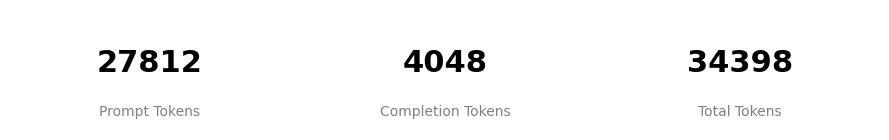

In [11]:
# Cell 9: Token KPI cards
df = run("""
SELECT
  COALESCE(SUM(prompt_tokens), 0) AS prompt,
  COALESCE(SUM(completion_tokens), 0) AS completion,
  COALESCE(SUM(total_tokens), 0) AS total
FROM llm_events
WHERE event_type = 'LLM_RESPONSE'
""")
kpi_row(
    ["Prompt Tokens", "Completion Tokens", "Total Tokens"],
    [df["prompt"][0], df["completion"][0], df["total"][0]],
)

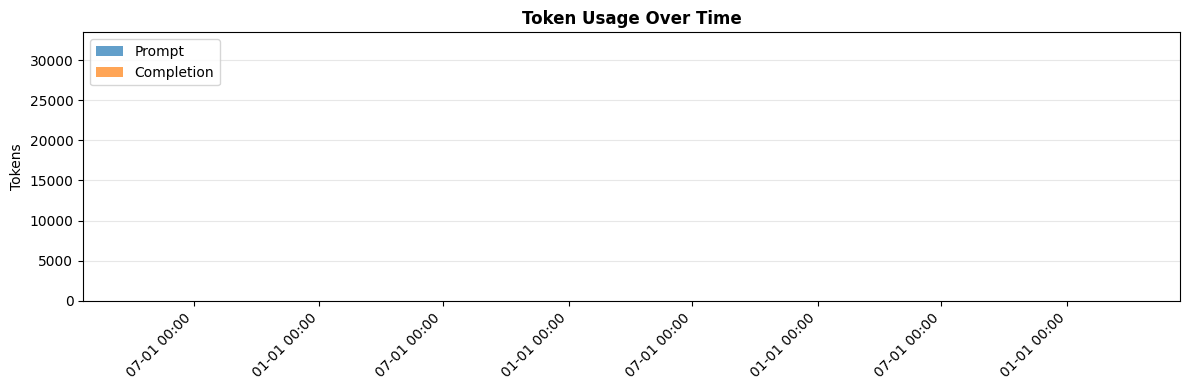

In [12]:
# Cell 10: Token usage over time
df = run("""
SELECT
  TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
  COALESCE(SUM(prompt_tokens), 0) AS prompt,
  COALESCE(SUM(completion_tokens), 0) AS completion
FROM llm_events
WHERE event_type = 'LLM_RESPONSE'
GROUP BY hour ORDER BY hour
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.stackplot(df["hour"], df["prompt"], df["completion"],
                 labels=["Prompt", "Completion"], alpha=0.7)
    fmt_ax(ax, "Token Usage Over Time", ylabel="Tokens")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No token data available.")

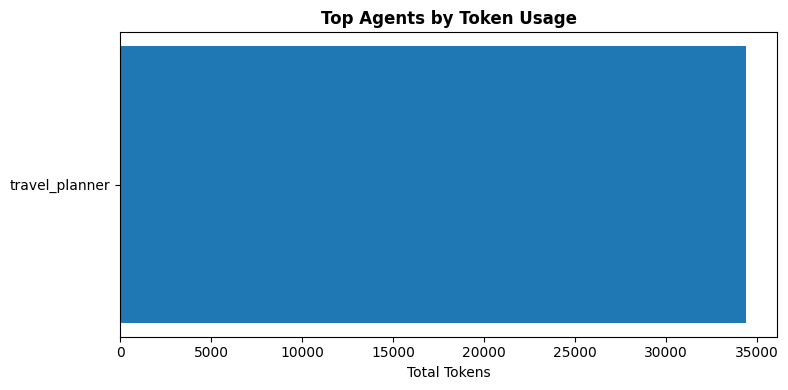

In [13]:
# Cell 11: Top agents by token usage
df = run("""
SELECT agent, COALESCE(SUM(total_tokens), 0) AS total
FROM llm_events WHERE event_type = 'LLM_RESPONSE'
GROUP BY agent ORDER BY total DESC LIMIT 10
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(df["agent"].fillna("(unknown)"), df["total"])
    ax.set_title("Top Agents by Token Usage", fontweight="bold")
    ax.set_xlabel("Total Tokens")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No agent token data.")

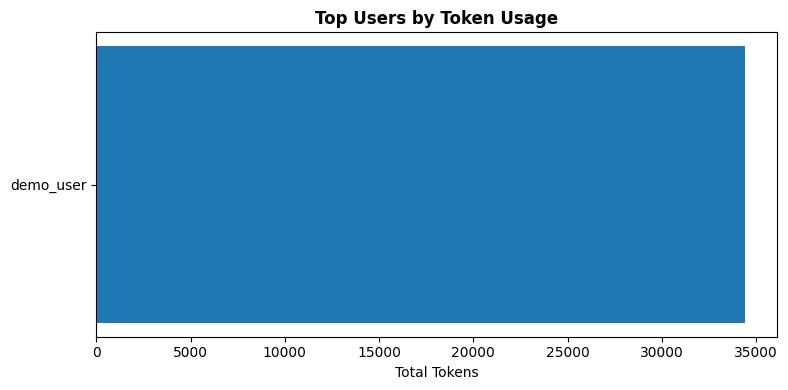

In [14]:
# Cell 12: Top users by token usage
df = run("""
SELECT user_id, COALESCE(SUM(total_tokens), 0) AS total
FROM llm_events WHERE event_type = 'LLM_RESPONSE'
GROUP BY user_id ORDER BY total DESC LIMIT 10
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(df["user_id"].fillna("(unknown)"), df["total"])
    ax.set_title("Top Users by Token Usage", fontweight="bold")
    ax.set_xlabel("Total Tokens")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No user token data.")

## Panel 2: Usage Volume

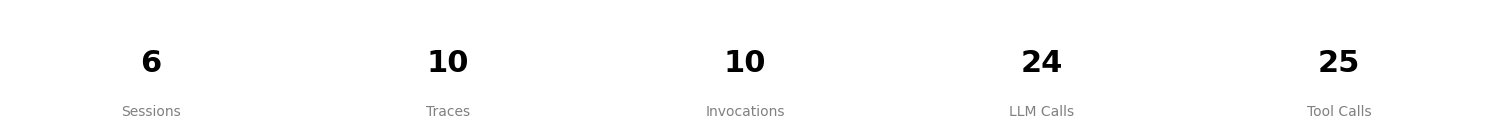

In [15]:
# Cell 13: Usage volume KPI cards
df = run("""
SELECT
  COUNT(*) AS sessions,
  COALESCE(SUM(trace_count), 0) AS traces,
  COALESCE(SUM(invocation_count), 0) AS invocations,
  COALESCE(SUM(llm_calls), 0) AS llm,
  COALESCE(SUM(tool_calls), 0) AS tools
FROM session_rollups
""")
kpi_row(
    ["Sessions", "Traces", "Invocations", "LLM Calls", "Tool Calls"],
    [df["sessions"][0], df["traces"][0], df["invocations"][0],
     df["llm"][0], df["tools"][0]],
)

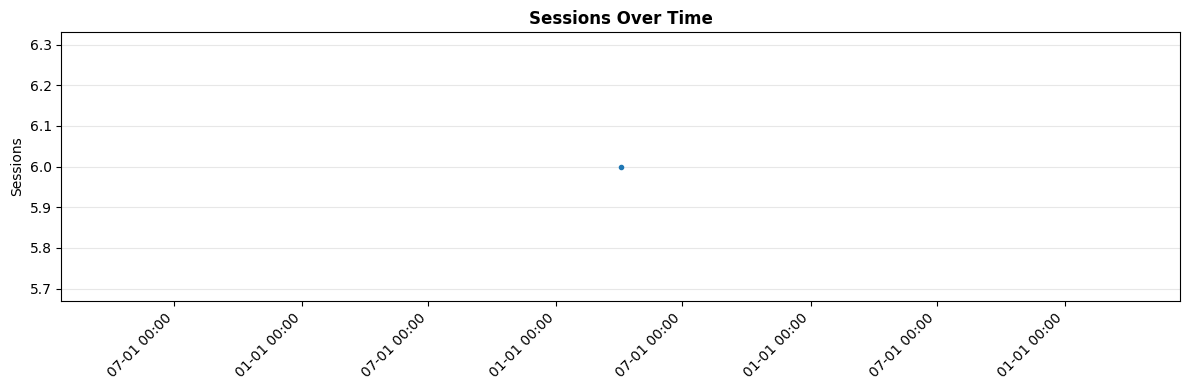

In [16]:
# Cell 14: Sessions over time
df = run("""
SELECT TIMESTAMP_TRUNC(start_ts, HOUR) AS hour, COUNT(*) AS sessions
FROM session_rollups GROUP BY hour ORDER BY hour
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["hour"], df["sessions"], marker="o", markersize=3)
    fmt_ax(ax, "Sessions Over Time", ylabel="Sessions")
    plt.tight_layout()
    plt.show()
else:
    print("No session data.")

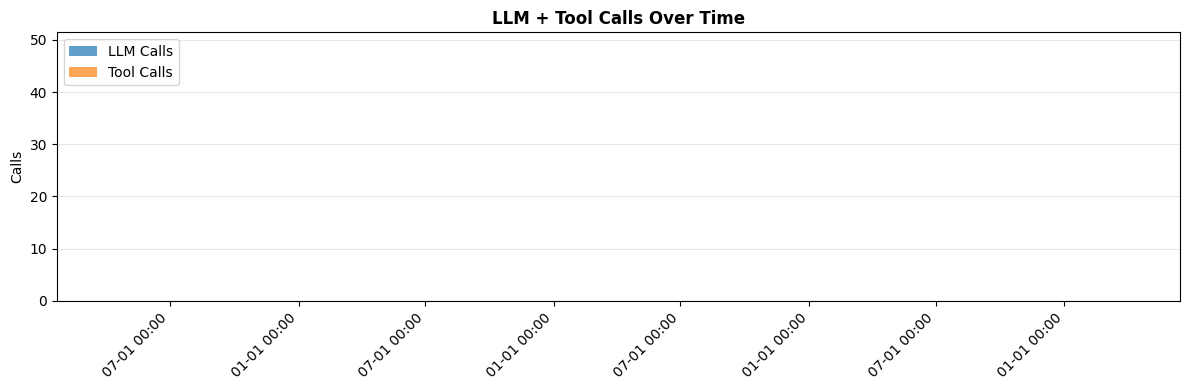

In [17]:
# Cell 15: LLM + Tool calls over time
df = run("""
SELECT
  TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
  COUNTIF(event_type = 'LLM_REQUEST') AS llm_calls,
  COUNTIF(event_type = 'TOOL_STARTING') AS tool_calls
FROM filtered_events
GROUP BY hour ORDER BY hour
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.stackplot(df["hour"], df["llm_calls"], df["tool_calls"],
                 labels=["LLM Calls", "Tool Calls"], alpha=0.7)
    fmt_ax(ax, "LLM + Tool Calls Over Time", ylabel="Calls")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No call data.")

## Panel 3: Reliability

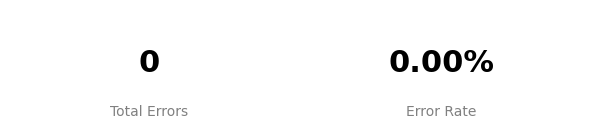

In [18]:
# Cell 16: Error KPI cards
df = run("""
SELECT
  COUNTIF(is_error) AS total_errors,
  SAFE_DIVIDE(COUNTIF(is_error), COUNT(*)) AS error_rate
FROM filtered_events
""")
rate_pct = f"{df['error_rate'][0] * 100:.2f}%" if df['error_rate'][0] else "0.00%"
kpi_row(["Total Errors", "Error Rate"], [df["total_errors"][0], rate_pct])

In [19]:
# Cell 17: Errors over time by event family
df = run("""
SELECT TIMESTAMP_TRUNC(timestamp, HOUR) AS hour, event_family, COUNT(*) AS errors
FROM filtered_events WHERE is_error
GROUP BY hour, event_family ORDER BY hour
""")
if not df.empty:
    pivot = df.pivot_table(index="hour", columns="event_family", values="errors", fill_value=0)
    fig, ax = plt.subplots(figsize=(12, 4))
    pivot.plot.area(ax=ax, alpha=0.7, stacked=True)
    fmt_ax(ax, "Errors Over Time by Event Family", ylabel="Errors")
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No errors found.")

No errors found.


In [20]:
# Cell 18: Tool errors by tool name + origin
df = run("""
SELECT
  COALESCE(tool_name, '(unknown)') AS tool,
  COALESCE(tool_origin, '(default)') AS origin,
  COUNT(*) AS errors
FROM tool_events WHERE is_error
GROUP BY tool, origin ORDER BY errors DESC LIMIT 15
""")
if not df.empty:
    labels = df["tool"] + " / " + df["origin"]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(labels, df["errors"])
    ax.set_title("Tool Errors by Name + Origin", fontweight="bold")
    ax.set_xlabel("Errors")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No tool errors.")

No tool errors.


In [21]:
# Cell 19: LLM errors by model
df = run("""
SELECT COALESCE(model, '(unknown)') AS model, COUNT(*) AS errors
FROM llm_events WHERE is_error
GROUP BY model ORDER BY errors DESC LIMIT 10
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(df["model"], df["errors"])
    ax.set_title("LLM Errors by Model", fontweight="bold")
    ax.set_xlabel("Errors")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No LLM errors.")

No LLM errors.


## Panel 4: Performance — Latency

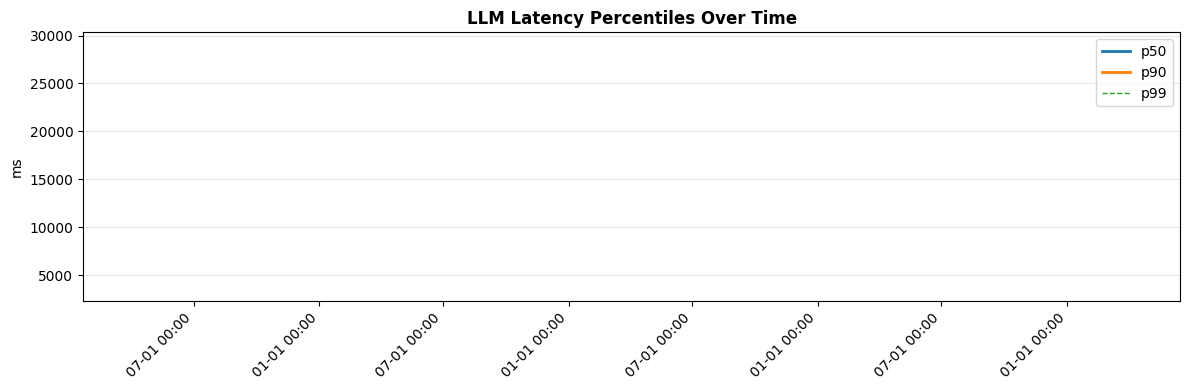

In [22]:
# Cell 20: LLM latency p50/p90/p99 over time
df = run("""
SELECT
  TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
  APPROX_QUANTILES(total_ms, 100)[OFFSET(50)] AS p50,
  APPROX_QUANTILES(total_ms, 100)[OFFSET(90)] AS p90,
  APPROX_QUANTILES(total_ms, 100)[OFFSET(99)] AS p99
FROM llm_events
WHERE event_type = 'LLM_RESPONSE' AND total_ms IS NOT NULL
GROUP BY hour ORDER BY hour
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["hour"], df["p50"], label="p50", linewidth=2)
    ax.plot(df["hour"], df["p90"], label="p90", linewidth=2)
    ax.plot(df["hour"], df["p99"], label="p99", linewidth=1, linestyle="--")
    fmt_ax(ax, "LLM Latency Percentiles Over Time", ylabel="ms")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No LLM latency data.")

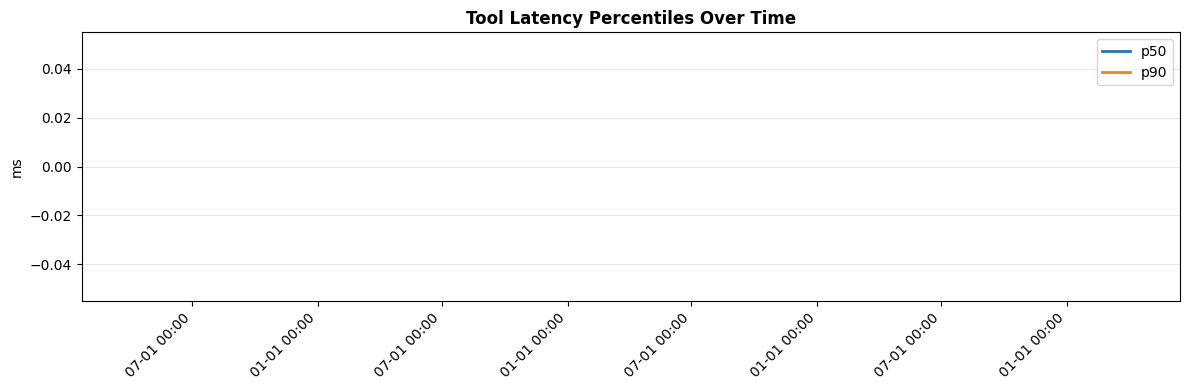

In [23]:
# Cell 21: Tool latency p50/p90 over time
df = run("""
SELECT
  TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
  APPROX_QUANTILES(total_ms, 100)[OFFSET(50)] AS p50,
  APPROX_QUANTILES(total_ms, 100)[OFFSET(90)] AS p90
FROM tool_events
WHERE event_type = 'TOOL_COMPLETED' AND total_ms IS NOT NULL
GROUP BY hour ORDER BY hour
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["hour"], df["p50"], label="p50", linewidth=2)
    ax.plot(df["hour"], df["p90"], label="p90", linewidth=2)
    fmt_ax(ax, "Tool Latency Percentiles Over Time", ylabel="ms")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No tool latency data.")

## Panel 5: Performance — TTFT (Time To First Token)

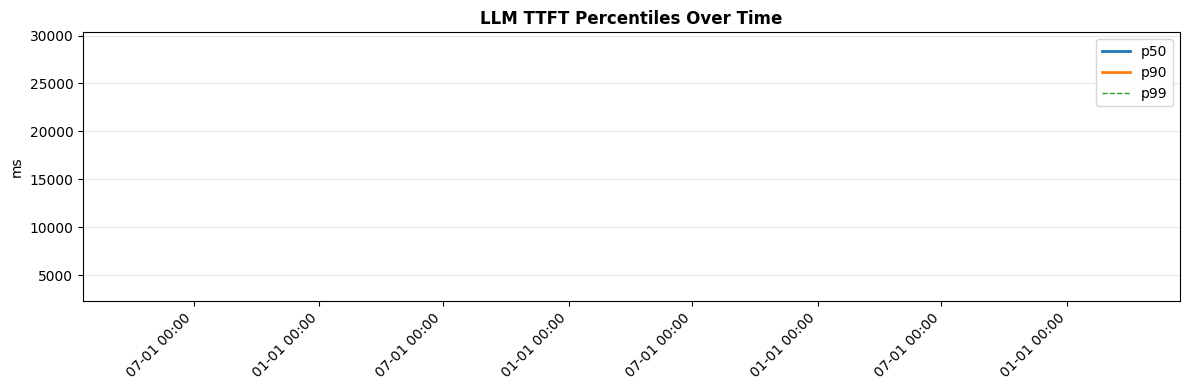

In [24]:
# Cell 22: TTFT p50/p90/p99 over time
df = run("""
SELECT
  TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
  APPROX_QUANTILES(ttft_ms, 100)[OFFSET(50)] AS p50,
  APPROX_QUANTILES(ttft_ms, 100)[OFFSET(90)] AS p90,
  APPROX_QUANTILES(ttft_ms, 100)[OFFSET(99)] AS p99
FROM llm_events
WHERE event_type = 'LLM_RESPONSE' AND ttft_ms IS NOT NULL
GROUP BY hour ORDER BY hour
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["hour"], df["p50"], label="p50", linewidth=2)
    ax.plot(df["hour"], df["p90"], label="p90", linewidth=2)
    ax.plot(df["hour"], df["p99"], label="p99", linewidth=1, linestyle="--")
    fmt_ax(ax, "LLM TTFT Percentiles Over Time", ylabel="ms")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No TTFT data (time_to_first_token_ms not emitted by all models).")

## Panel 6: Session Duration

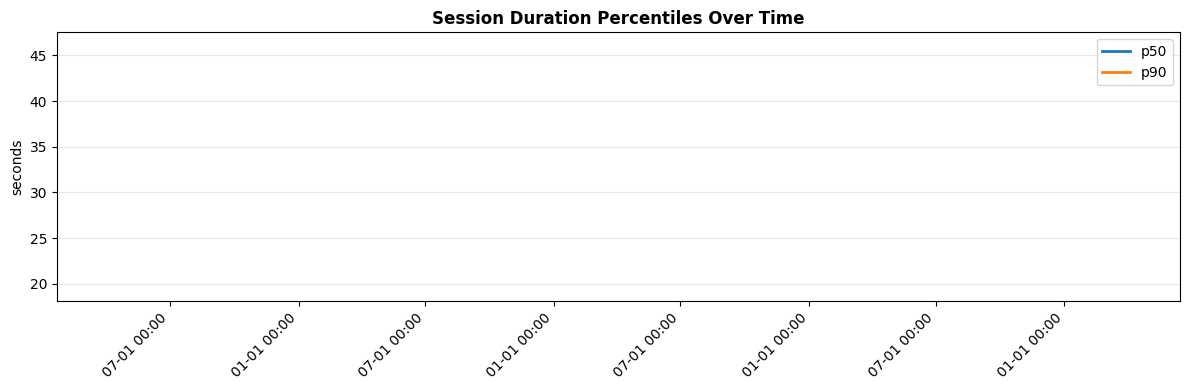

In [25]:
# Cell 23: Session duration p50/p90 over time
df = run("""
SELECT
  TIMESTAMP_TRUNC(start_ts, HOUR) AS hour,
  APPROX_QUANTILES(duration_ms, 100)[OFFSET(50)] AS p50,
  APPROX_QUANTILES(duration_ms, 100)[OFFSET(90)] AS p90
FROM session_rollups
WHERE duration_ms > 0
GROUP BY hour ORDER BY hour
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["hour"], df["p50"] / 1000, label="p50", linewidth=2)
    ax.plot(df["hour"], df["p90"] / 1000, label="p90", linewidth=2)
    fmt_ax(ax, "Session Duration Percentiles Over Time", ylabel="seconds")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No session duration data.")

## Panel 7: Users

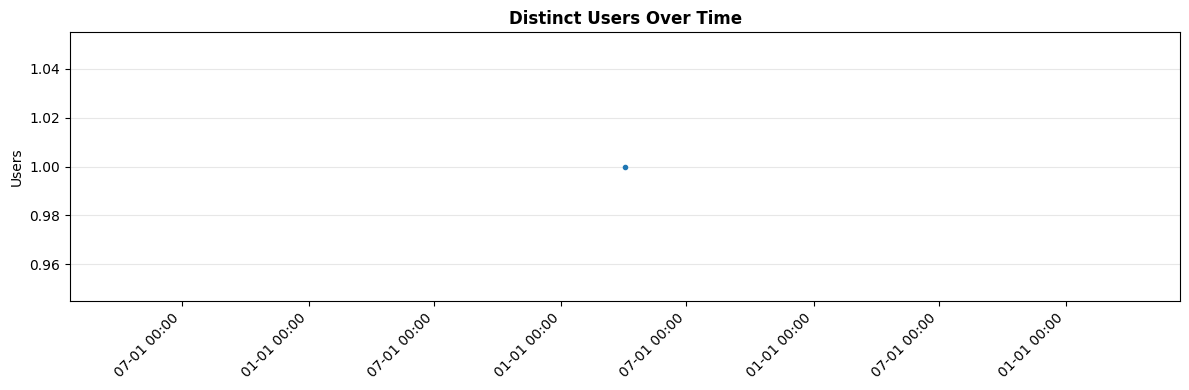

In [26]:
# Cell 24: Distinct users over time
df = run("""
SELECT TIMESTAMP_TRUNC(start_ts, HOUR) AS hour,
       COUNT(DISTINCT user_id) AS users
FROM session_rollups
GROUP BY hour ORDER BY hour
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["hour"], df["users"], marker="o", markersize=3)
    fmt_ax(ax, "Distinct Users Over Time", ylabel="Users")
    plt.tight_layout()
    plt.show()
else:
    print("No user data.")

In [27]:
# Cell 25: Top users by sessions
df = run("""
SELECT COALESCE(user_id, '(unknown)') AS user_id, COUNT(*) AS sessions
FROM session_rollups GROUP BY user_id ORDER BY sessions DESC LIMIT 10
""")
if not df.empty:
    print("Top Users by Session Count:")
    print(df.to_string(index=False))
else:
    print("No user session data.")

Top Users by Session Count:
  user_id  sessions
demo_user         6


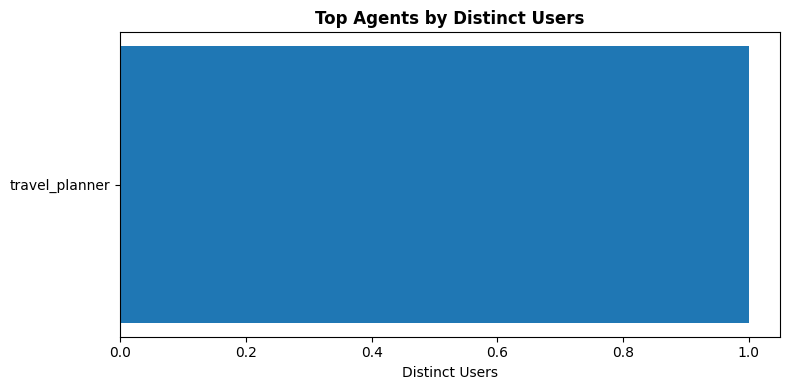

In [28]:
# Cell 26: Top agents by distinct users
df = run("""
SELECT COALESCE(agent, '(unknown)') AS agent, COUNT(DISTINCT user_id) AS users
FROM session_rollups GROUP BY agent ORDER BY users DESC LIMIT 10
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(df["agent"], df["users"])
    ax.set_title("Top Agents by Distinct Users", fontweight="bold")
    ax.set_xlabel("Distinct Users")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No agent user data.")

## Panel 8: HITL / Orchestration

In [29]:
# Cell 27: HITL requests over time by type
df = run("""
SELECT TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
       hitl_type, COUNT(*) AS requests
FROM hitl_events WHERE NOT is_completed
GROUP BY hour, hitl_type ORDER BY hour
""")
if not df.empty:
    pivot = df.pivot_table(index="hour", columns="hitl_type", values="requests", fill_value=0)
    fig, ax = plt.subplots(figsize=(12, 4))
    pivot.plot.area(ax=ax, alpha=0.7, stacked=True)
    fmt_ax(ax, "HITL Requests Over Time by Type", ylabel="Requests")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No HITL events found.")

No HITL events found.


In [30]:
# Cell 28: HITL completion rate by type
df = run("""
SELECT hitl_type,
       COUNTIF(NOT is_completed) AS requests,
       COUNTIF(is_completed) AS completions
FROM hitl_events
GROUP BY hitl_type
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    x = range(len(df))
    w = 0.35
    ax.bar([i - w/2 for i in x], df["requests"], w, label="Requests")
    ax.bar([i + w/2 for i in x], df["completions"], w, label="Completions")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df["hitl_type"].fillna("(unknown)"))
    ax.set_title("HITL Completion Rate by Type", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No HITL events found.")

No HITL events found.


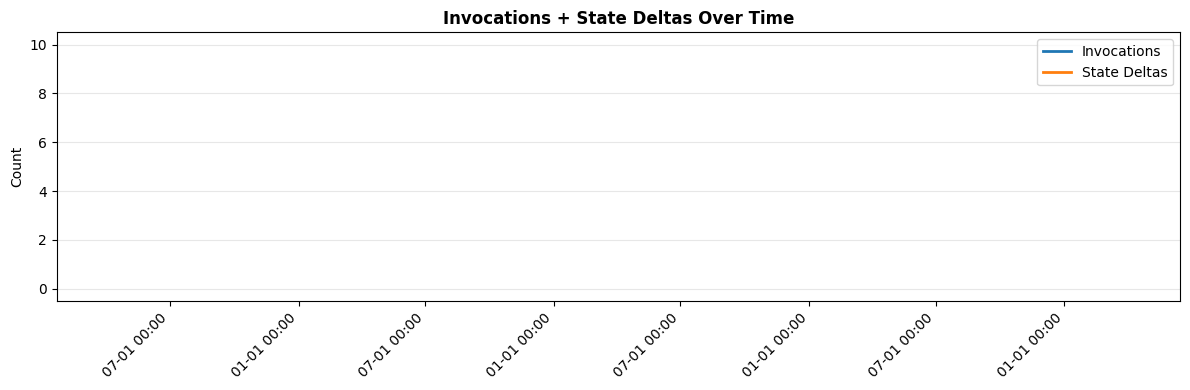

In [31]:
# Cell 29: Invocations + state deltas over time
df = run("""
SELECT TIMESTAMP_TRUNC(start_ts, HOUR) AS hour,
       SUM(invocation_count) AS invocations,
       SUM(state_deltas) AS state_deltas
FROM session_rollups
GROUP BY hour ORDER BY hour
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["hour"], df["invocations"], label="Invocations", linewidth=2)
    ax.plot(df["hour"], df["state_deltas"], label="State Deltas", linewidth=2)
    fmt_ax(ax, "Invocations + State Deltas Over Time", ylabel="Count")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No invocation data.")

## Panel 9: Multimodal

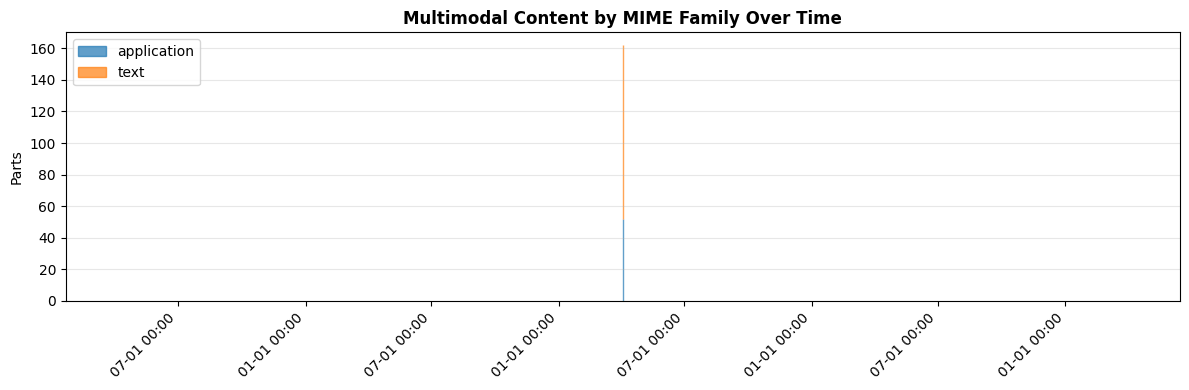

In [32]:
# Cell 30: Content by mime_family over time
df = run("""
SELECT TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
       COALESCE(mime_family, '(unknown)') AS mime_family,
       COUNT(*) AS parts
FROM multimodal_parts
GROUP BY hour, mime_family ORDER BY hour
""")
if not df.empty:
    pivot = df.pivot_table(index="hour", columns="mime_family", values="parts", fill_value=0)
    fig, ax = plt.subplots(figsize=(12, 4))
    pivot.plot.area(ax=ax, alpha=0.7, stacked=True)
    fmt_ax(ax, "Multimodal Content by MIME Family Over Time", ylabel="Parts")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No multimodal content found.")

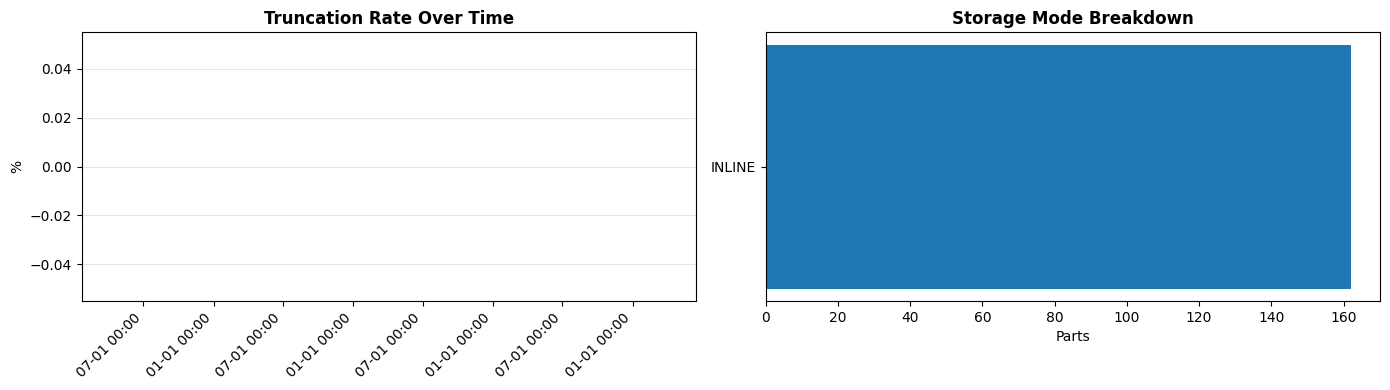

In [33]:
# Cell 31: Truncation rate + storage mode breakdown
df_trunc = run("""
SELECT TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
       SAFE_DIVIDE(COUNTIF(is_truncated), COUNT(*)) AS truncation_rate
FROM multimodal_parts
GROUP BY hour ORDER BY hour
""")
df_storage = run("""
SELECT COALESCE(storage_mode, '(unset)') AS storage_mode, COUNT(*) AS parts
FROM multimodal_parts
GROUP BY storage_mode ORDER BY parts DESC
""")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
if not df_trunc.empty:
    ax1.plot(df_trunc["hour"], df_trunc["truncation_rate"] * 100, linewidth=2, color="red")
    ax1.set_title("Truncation Rate Over Time", fontweight="bold")
    ax1.set_ylabel("%")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:00"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax1.grid(axis="y", alpha=0.3)
else:
    ax1.text(0.5, 0.5, "No truncation data", ha="center", va="center", transform=ax1.transAxes)
    ax1.set_title("Truncation Rate", fontweight="bold")
if not df_storage.empty:
    ax2.barh(df_storage["storage_mode"], df_storage["parts"])
    ax2.set_title("Storage Mode Breakdown", fontweight="bold")
    ax2.set_xlabel("Parts")
    ax2.invert_yaxis()
else:
    ax2.text(0.5, 0.5, "No storage mode data", ha="center", va="center", transform=ax2.transAxes)
    ax2.set_title("Storage Mode", fontweight="bold")
plt.tight_layout()
plt.show()

---
# Section 10: Trace Drill-Down

**Separate section, different success criterion.**

The aggregate dashboard answers "how is the system doing?"
The drill-down answers "what happened in this specific trace?"

Set `SESSION_ID_FILTER` or `TRACE_ID_FILTER` above and re-run Layer 1 to scope the drill-down.

In [34]:
# Cell 32: Session list
df = run("""
SELECT
  session_id,
  agent,
  start_ts,
  end_ts,
  duration_ms,
  total_events,
  has_error,
  has_multimodal,
  trace_count
FROM session_rollups
ORDER BY start_ts DESC
LIMIT 30
""")
print(f"Recent sessions ({len(df)} shown):")
print(df.to_string(index=False))

Recent sessions (6 shown):
      session_id          agent                         start_ts                           end_ts  duration_ms  total_events  has_error  has_multimodal  trace_count
e2e-a9b40dfdbe84 travel_planner 2026-04-03 07:44:09.959171+00:00 2026-04-03 07:44:56.141283+00:00        46182            33      False            True            3
e2e-054c12957ba3 travel_planner 2026-04-03 07:43:59.632517+00:00 2026-04-03 07:44:09.553076+00:00         9920            19      False            True            1
e2e-781fb52f3814 travel_planner 2026-04-03 07:43:46.386415+00:00 2026-04-03 07:43:59.242929+00:00        12856            21      False            True            1
e2e-3171eb36991f travel_planner 2026-04-03 07:37:14.206646+00:00 2026-04-03 07:37:40.342719+00:00        26136            33      False            True            3
e2e-f676e06a719e travel_planner 2026-04-03 07:36:54.241866+00:00 2026-04-03 07:37:13.697492+00:00        19455            19      False            T

In [35]:
# Cell 33: Span tree for a session
# Pick the most recent session (or set SESSION_ID_FILTER above)
target_session = df["session_id"].iloc[0] if not df.empty else None

if target_session:
    spans = run(f"""
    SELECT
      span_id,
      parent_span_id,
      event_type,
      event_family,
      agent,
      status,
      error_message,
      CAST(JSON_VALUE(latency_ms, '$.total_ms') AS FLOAT64) AS total_ms,
      CAST(JSON_VALUE(latency_ms, '$.time_to_first_token_ms') AS FLOAT64) AS ttft_ms,
      timestamp
    FROM filtered_events
    WHERE session_id = '{target_session}'
    ORDER BY timestamp
    """)

    # Build tree from parent_span_id
    children = {}
    roots = []
    for _, row in spans.iterrows():
        pid = row.get("parent_span_id")
        if pid and pid in spans["span_id"].values:
            children.setdefault(pid, []).append(row)
        else:
            roots.append(row)

    def print_tree(node, indent=0):
        sid = node.get("span_id", "?")[:8] if node.get("span_id") else "?"
        et = node.get("event_type", "")
        ag = node.get("agent", "")
        st = node.get("status", "")
        lat = node.get("total_ms")
        err = node.get("error_message")
        prefix = "  " * indent
        err_mark = " *** ERROR" if err else ""
        lat_str = f" ({lat:.0f}ms)" if lat and lat > 0 else ""
        print(f"{prefix}[{sid}] {et} agent={ag} status={st}{lat_str}{err_mark}")
        if err:
            print(f"{prefix}  error: {str(err)[:100]}")
        for child in children.get(node.get("span_id"), []):
            print_tree(child, indent + 1)

    print(f"Span tree for session: {target_session}")
    print(f"Total spans: {len(spans)}")
    print("=" * 70)
    for root in roots:
        print_tree(root)
else:
    print("No sessions available for drill-down.")

Span tree for session: e2e-a9b40dfdbe84
Total spans: 33
[1c5d2a3d] USER_MESSAGE_RECEIVED agent=travel_planner status=OK
  [4da56afc] AGENT_STARTING agent=travel_planner status=OK
    [ca1069a7] LLM_REQUEST agent=travel_planner status=OK
    [ca1069a7] LLM_RESPONSE agent=travel_planner status=OK (2148ms)
    [0c421077] TOOL_STARTING agent=travel_planner status=OK
    [0c421077] TOOL_COMPLETED agent=travel_planner status=OK
    [cb1f5828] LLM_REQUEST agent=travel_planner status=OK
    [cb1f5828] LLM_RESPONSE agent=travel_planner status=OK (1914ms)
  [4da56afc] AGENT_COMPLETED agent=travel_planner status=OK (4077ms)
    [ca1069a7] LLM_REQUEST agent=travel_planner status=OK
    [ca1069a7] LLM_RESPONSE agent=travel_planner status=OK (2148ms)
    [0c421077] TOOL_STARTING agent=travel_planner status=OK
    [0c421077] TOOL_COMPLETED agent=travel_planner status=OK
    [cb1f5828] LLM_REQUEST agent=travel_planner status=OK
    [cb1f5828] LLM_RESPONSE agent=travel_planner status=OK (1914ms)
[1c5d2

In [36]:
# Cell 34: Span detail — pick a span to inspect
if target_session:
    detail = run(f"""
    SELECT
      span_id, parent_span_id, event_type, agent, status,
      error_message, is_truncated,
      JSON_VALUE(latency_ms, '$.total_ms') AS total_ms,
      JSON_VALUE(latency_ms, '$.time_to_first_token_ms') AS ttft_ms,
      SUBSTR(TO_JSON_STRING(content), 0, 500) AS content_preview,
      SUBSTR(TO_JSON_STRING(attributes), 0, 500) AS attributes_preview,
      ARRAY_LENGTH(content_parts) AS content_parts_count,
      timestamp
    FROM filtered_events
    WHERE session_id = '{target_session}'
    ORDER BY timestamp
    LIMIT 20
    """)
    for _, row in detail.iterrows():
        print(f"--- {row['event_type']} (span: {str(row.get('span_id',''))[:8]}) ---")
        print(f"  agent: {row.get('agent')}  status: {row.get('status')}")
        if row.get("total_ms"):
            print(f"  latency: {row['total_ms']}ms", end="")
            if row.get("ttft_ms"):
                print(f"  ttft: {row['ttft_ms']}ms", end="")
            print()
        if row.get("error_message"):
            print(f"  error: {str(row['error_message'])[:200]}")
        if row.get("content_parts_count") and int(row["content_parts_count"]) > 0:
            print(f"  multimodal: {row['content_parts_count']} part(s)")
        if row.get("content_preview"):
            print(f"  content: {str(row['content_preview'])[:200]}...")
        print()
else:
    print("No session selected.")

--- USER_MESSAGE_RECEIVED (span: 1c5d2a3d) ---
  agent: travel_planner  status: OK
  multimodal: 1 part(s)
  content: {"text_summary":"What's the weather like in Paris on 2025-04-20?"}...

--- INVOCATION_STARTING (span: 1c5d2a3d) ---
  agent: travel_planner  status: OK
  content: null...

--- AGENT_STARTING (span: 4da56afc) ---
  agent: travel_planner  status: OK
  content: "You are a helpful travel planning assistant. You help users plan trips by\nsearching for flights, hotels, checking weather forecasts, and calculating\nbudgets.\n\nGuidelines:\n- Always search for fli...

--- LLM_REQUEST (span: ca1069a7) ---
  agent: travel_planner  status: OK
  multimodal: 1 part(s)
  content: {"prompt":[{"content":"What's the weather like in Paris on 2025-04-20?","role":"user"}],"system_prompt":"You are a helpful travel planning assistant. You help users plan trips by\nsearching for flight...

--- LLM_RESPONSE (span: ca1069a7) ---
  agent: travel_planner  status: OK
  latency: 2148ms  ttft: 2148ms

In [37]:
# Cell 35: Error chain — trace error propagation
if target_session:
    errors = run(f"""
    SELECT span_id, parent_span_id, event_type, agent, error_message,
           CAST(JSON_VALUE(latency_ms, '$.total_ms') AS FLOAT64) AS total_ms,
           timestamp
    FROM filtered_events
    WHERE session_id = '{target_session}'
      AND (ENDS_WITH(event_type, '_ERROR')
           OR error_message IS NOT NULL
           OR status = 'ERROR')
    ORDER BY timestamp
    """)
    if not errors.empty:
        # Build span lookup for the full session
        all_spans = run(f"""
        SELECT span_id, parent_span_id, event_type, agent
        FROM filtered_events
        WHERE session_id = '{target_session}'
        """)
        span_map = {r["span_id"]: r for _, r in all_spans.iterrows() if r.get("span_id")}

        print(f"Error chain for session: {target_session}")
        print(f"Found {len(errors)} error event(s):")
        print("=" * 70)
        for _, err in errors.iterrows():
            print(f"\nError: {err['event_type']} (agent={err.get('agent')})")
            print(f"  message: {str(err.get('error_message',''))[:200]}")
            # Walk up to root
            chain = []
            current = err.get("span_id")
            visited = set()
            while current and current in span_map and current not in visited:
                visited.add(current)
                s = span_map[current]
                chain.append(f"{s.get('event_type','')} [agent={s.get('agent','')}]")
                current = s.get("parent_span_id")
            if chain:
                print("  propagation path (leaf → root):")
                for i, step in enumerate(chain):
                    print(f"    {'  ' * i}→ {step}")
    else:
        print("No errors in this session.")
else:
    print("No session selected.")

No errors in this session.


---

In [38]:
print("Dashboard V2 complete.")
print(f"  Layers: 7 base tables (Layer 1) + 23 charts + 4 drill-down views (Layer 2)")
print(f"  Data source: {TABLE_REF}")
print(f"  Time range: last {TIME_RANGE_HOURS} hours")

# Clean up BigQuery session
try:
    client.query(f"CALL BQ.ABORT_SESSION('{SESSION_ID}')", job_config=_job_config()).result()
    print(f"  Session {SESSION_ID[:16]}... closed.")
except Exception:
    print(f"  Session will auto-expire.")

Dashboard V2 complete.
  Layers: 7 base tables (Layer 1) + 23 charts + 4 drill-down views (Layer 2)
  Data source: `test-project-0728-467323.agent_analytics.agent_events`
  Time range: last 720 hours


  Session ChoKGHRlc3QtcHJv... closed.
